In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

-----

Few Points about why feature redundancy is bad

1. Statistical Problems

Multicollinearity → unstable regression coefficients

Inflated variance → bad generalization

2. ML Problems

Tree models split on random correlated features

Overfitting is very high

3. Basically one alpha repeated n times

---------   

In [2]:
df = pd.read_parquet("/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Data/processed/splits/train.parquet")
df["date"] = pd.to_datetime(df["date"])

feature_cols = [c for c in df.columns if c not in ["date", "ticker", "fwd_return_5d"]]
print(len(feature_cols))

68


In [3]:
rank_cols = [col for col in df.columns if '_rank' in col]
df = df.drop(columns=rank_cols)

df

,date,ticker,fwd_return_5d,dollar_volume,price_ma_ratio_5,price_ma_ratio_10,price_ma_ratio_21,price_ma_ratio_63,price_ma_ratio_252,pos_days_21,...,downside_vol_1d,downside_vol_5d,vol_avg_5,vol_avg_21,vol_avg_63,dollar_vol_log,volume_trend,mom_x_vol_5,mom_x_vol_21,mom_x_vol_63
0,2011-01-03,AAPL,0.039081,4.399815e+09,0.013095,0.015186,0.022646,0.053737,0.266111,0.571429,...,0.002118,0.001247,227040800.0,3.092279e+08,4.488507e+08,22.204828,-8.312502e+06,3.419588e+06,1.109984e+07,8.204138e+07
1,2011-01-04,AAPL,0.031242,3.070944e+09,0.014752,0.017638,0.025883,0.056965,0.270454,0.619048,...,0.002138,0.001247,253672160.0,3.076559e+08,4.457890e+08,21.845251,-7.844913e+06,4.536055e+06,1.342301e+07,6.533927e+07
2,2011-01-05,AAPL,0.031198,2.559542e+09,0.017622,0.022883,0.032167,0.063198,0.278453,0.619048,...,0.002138,0.001247,272148240.0,2.984672e+08,4.391961e+08,21.663094,-6.510211e+06,7.287014e+06,1.291194e+07,6.805336e+07
3,2011-01-06,AAPL,0.035807,3.006965e+09,0.010599,0.019381,0.028983,0.059955,0.275035,0.619048,...,0.001858,0.001247,300735120.0,2.941327e+08,4.374823e+08,21.824197,-5.156353e+06,9.356793e+06,1.434567e+07,6.732704e+07
4,2011-01-07,AAPL,0.036773,3.144450e+09,0.009545,0.022770,0.034058,0.065287,0.281753,0.619048,...,0.001858,0.001247,324419760.0,2.936563e+08,4.319828e+08,21.868905,-4.528018e+06,1.363817e+07,1.382247e+07,6.177061e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109279,2021-12-27,XOM,0.026660,6.762030e+08,0.019403,0.015589,0.010677,-0.002264,0.102931,0.571429,...,0.010966,0.017684,16362700.0,2.192815e+07,2.103481e+07,20.332004,-4.292123e+05,5.069886e+05,-5.492418e+05,1.213762e+06
109280,2021-12-28,XOM,0.068731,6.840421e+08,0.007710,0.012208,0.007066,-0.006141,0.097630,0.571429,...,0.008782,0.017253,14555040.0,2.134727e+07,2.064055e+07,20.343530,-5.044144e+05,6.224543e+05,1.533547e+05,8.952968e+05
109281,2021-12-29,XOM,0.091578,6.755398e+08,-0.003227,0.003990,-0.001407,-0.015360,0.086314,0.523810,...,0.008745,0.017253,13141980.0,2.105142e+07,2.047088e+07,20.331023,-6.505783e+05,1.411958e+05,-1.503915e+05,7.151160e+05
109282,2021-12-30,XOM,0.123869,6.297245e+08,-0.008449,-0.001134,-0.008019,-0.021845,0.078277,0.523810,...,0.006973,0.017101,12718380.0,1.995430e+07,2.016375e+07,20.260793,-5.699277e+05,-4.170689e+04,3.167861e+05,9.553846e+05


In [4]:
feature_cols = [c for c in df.columns if c not in ["date", "ticker", "fwd_return_5d"]]
print(len(feature_cols))

34


-------

1. Cross Sectional Correlation Matrix

--------

In [5]:
corr_list = []

for dt, g in df.groupby('date'):
    
    corr = g[feature_cols].corr()
    corr_list.append(corr)

avg_corr = pd.concat(corr_list).groupby(level=0).mean()

In [6]:
avg_corr

,dollar_volume,price_ma_ratio_5,price_ma_ratio_10,price_ma_ratio_21,price_ma_ratio_63,price_ma_ratio_252,pos_days_21,z_price_21,z_price_63,z_return_1d_5,...,downside_vol_1d,downside_vol_5d,vol_avg_5,vol_avg_21,vol_avg_63,dollar_vol_log,volume_trend,mom_x_vol_5,mom_x_vol_21,mom_x_vol_63
dollar_vol_log,0.838950,0.052007,0.063787,0.076968,0.111050,0.199622,0.014649,0.028028,0.029875,0.012647,...,0.139507,0.091851,0.424234,0.406809,0.402509,1.000000,0.074269,0.090846,0.133430,0.215514
dollar_volume,1.000000,0.060200,0.073940,0.090604,0.129709,0.225117,0.024114,0.037851,0.042992,0.013259,...,0.176351,0.113549,0.493418,0.472822,0.468245,0.838950,0.088699,0.107123,0.148566,0.244094
downside_vol_1d,0.176351,-0.113683,-0.170206,-0.256386,-0.222913,-0.011095,-0.131625,-0.293514,-0.343588,-0.016030,...,1.000000,0.818456,0.324229,0.326818,0.308613,0.139507,0.014261,-0.048644,-0.083111,0.054328
downside_vol_5d,0.113549,-0.092550,-0.206163,-0.365341,-0.402983,-0.158312,-0.299645,-0.354968,-0.459729,0.038970,...,0.818456,1.000000,0.250131,0.257588,0.245631,0.091851,-0.019126,-0.080659,-0.191397,-0.046171
hl_range,0.247878,0.052792,0.057756,0.062585,0.083460,0.158933,-0.049409,-0.013916,-0.020483,0.042000,...,0.533607,0.409196,0.335536,0.314163,0.307379,0.227506,0.093443,0.064735,0.091919,0.153275
mom_x_vol_21,0.148566,0.207644,0.315641,0.493894,0.517818,0.350759,0.236157,0.276759,0.312278,0.008705,...,-0.083111,-0.191397,0.250577,0.250079,0.236061,0.133430,0.009306,0.428883,1.000000,0.528143
mom_x_vol_5,0.107123,0.464380,0.547230,0.450721,0.301667,0.190392,0.131015,0.298805,0.253674,0.040243,...,-0.048644,-0.080659,0.156612,0.137540,0.132957,0.090846,0.036986,1.000000,0.428883,0.260217
mom_x_vol_63,0.244094,0.123110,0.183420,0.276248,0.510455,0.527645,0.122443,0.146901,0.204520,0.008291,...,0.054328,-0.046171,0.413606,0.419945,0.420291,0.215514,0.009662,0.260217,0.528143,1.000000
pos_days_21,0.024114,0.230469,0.325927,0.470242,0.443961,0.271336,1.000000,0.473152,0.523720,-0.006277,...,-0.131625,-0.299645,-0.006490,-0.008979,-0.012282,0.014649,0.024333,0.131015,0.236157,0.122443
price_ma_ratio_10,0.073940,0.844071,1.000000,0.844417,0.531907,0.286547,0.325927,0.764330,0.650841,0.160437,...,-0.170206,-0.206163,0.064077,0.049509,0.047100,0.063787,0.047310,0.547230,0.315641,0.183420


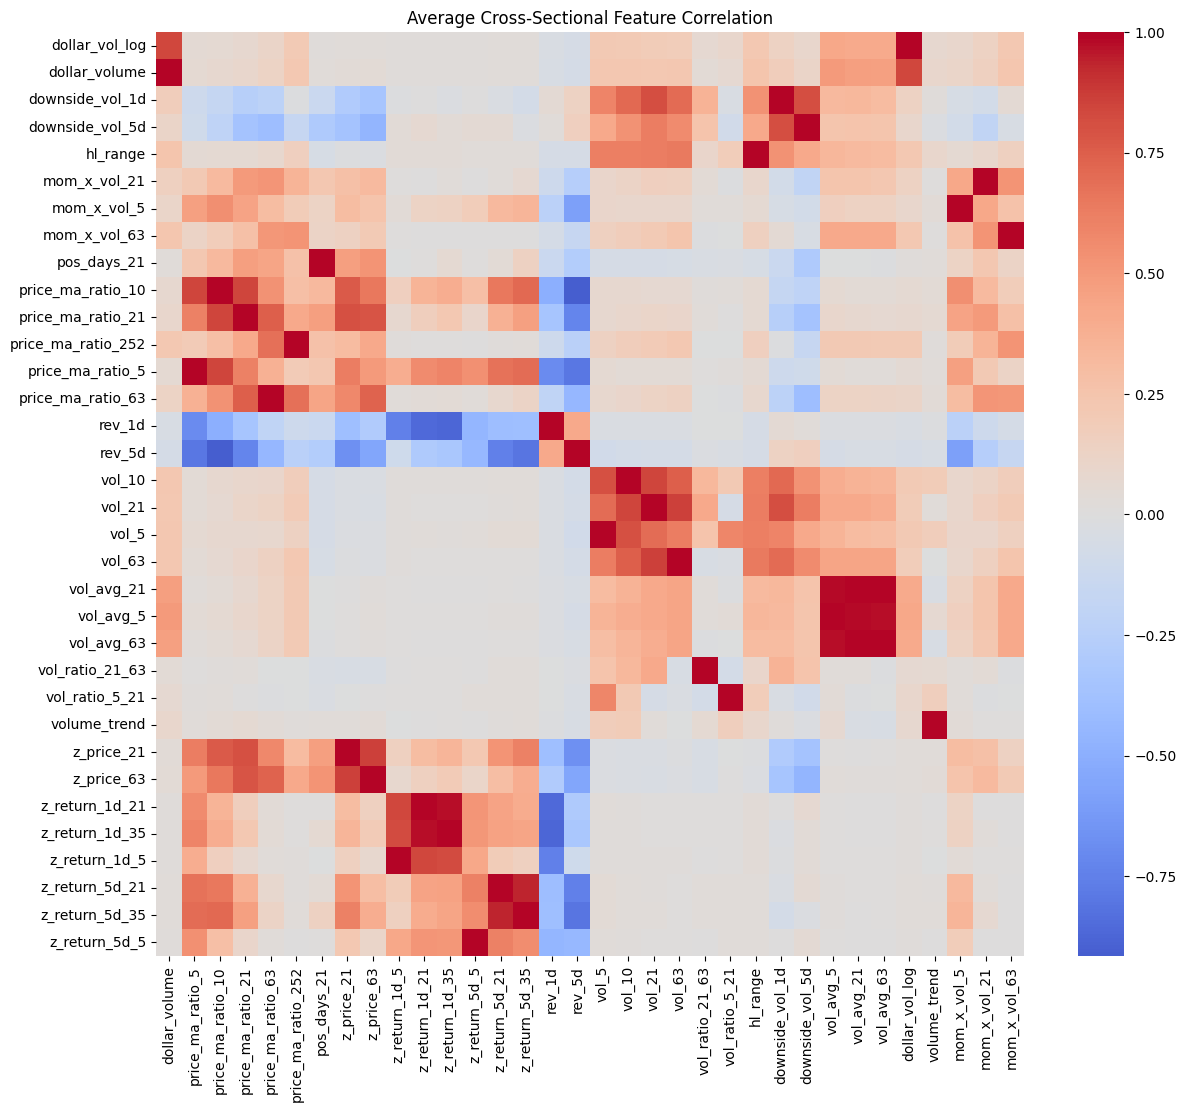

In [7]:
plt.figure(figsize=(14,12))
sns.heatmap(avg_corr, cmap="coolwarm", center=0, xticklabels=True, yticklabels=True)
plt.title("Average Cross-Sectional Feature Correlation")
plt.show()

------

2. Converting Correlation to Distance matrix

--------

This builds a tree structure of features.

Start with each feature as its own group, then merge the two most similar, then next closest and keep repeating until everything becomes one cluster

This creates a hierarchy of feature similarity.

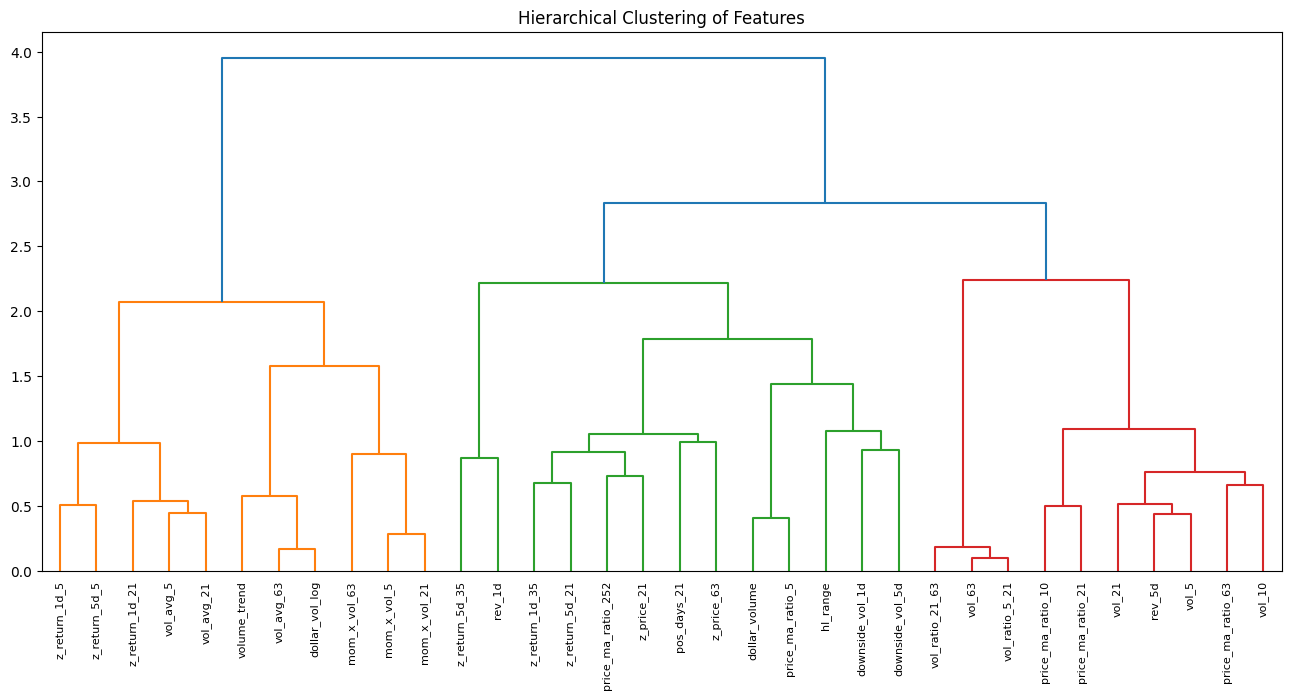

In [8]:
distance = np.sqrt(0.5 * (1 - avg_corr))

link = linkage(distance, method="ward")

plt.figure(figsize=(16,7))
dendrogram(link, labels=feature_cols, leaf_rotation=90)
plt.title("Hierarchical Clustering of Features")
plt.show()

Features that merge very low are very similar, thus redundant. If they merge higher, they are more independant so its important to keep both

---------

3. Creating Clusters

------

In [9]:
k = 6
clusters = fcluster(link, k, criterion="maxclust")

cluster_df = pd.DataFrame({
    "feature": feature_cols,
    "cluster": clusters
})

cluster_df.sort_values("cluster").head(20)

,feature,cluster
27,vol_avg_21,1
26,vol_avg_5,1
9,z_return_1d_5,1
10,z_return_1d_21,1
12,z_return_5d_5,1
33,mom_x_vol_63,2
31,mom_x_vol_5,2
30,volume_trend,2
29,dollar_vol_log,2
28,vol_avg_63,2


In [10]:
for i in range(1, k+1):
    feats = cluster_df[cluster_df["cluster"] == i]["feature"].tolist()
    print(f"\nCluster {i} ({len(feats)} features)")
    print(feats)


Cluster 1 (5 features)
['z_return_1d_5', 'z_return_1d_21', 'z_return_5d_5', 'vol_avg_5', 'vol_avg_21']

Cluster 2 (6 features)
['vol_avg_63', 'dollar_vol_log', 'volume_trend', 'mom_x_vol_5', 'mom_x_vol_21', 'mom_x_vol_63']

Cluster 3 (2 features)
['z_return_5d_35', 'rev_1d']

Cluster 4 (11 features)
['dollar_volume', 'price_ma_ratio_5', 'price_ma_ratio_252', 'pos_days_21', 'z_price_21', 'z_price_63', 'z_return_1d_35', 'z_return_5d_21', 'hl_range', 'downside_vol_1d', 'downside_vol_5d']

Cluster 5 (3 features)
['vol_63', 'vol_ratio_21_63', 'vol_ratio_5_21']

Cluster 6 (7 features)
['price_ma_ratio_10', 'price_ma_ratio_21', 'price_ma_ratio_63', 'rev_5d', 'vol_5', 'vol_10', 'vol_21']


4. Cluster Representative Selection

This part involves selecting one representative per cluster. A good method: Feature with highest IC t-stat inside each cluster

In [11]:
ic_df = pd.read_parquet("/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Data/processed/ic_df.parquet")
ic_df.head()

,feature,mean,std,count,t_stat,IR,nw_t,nw_p,boot_p
0,dollar_vol_log,-0.003609,0.218123,2769,-0.870677,-0.016546,-0.478524,0.632277,0.649667
1,dollar_volume,-0.003609,0.218123,2769,-0.870677,-0.016546,-0.478524,0.632277,0.659000
2,downside_vol_1d,0.017557,0.285499,2769,3.236018,0.061496,1.767612,0.077126,0.110667
3,downside_vol_5d,0.015319,0.269147,2769,2.995134,0.056919,1.632336,0.102609,0.145333
4,hl_range,0.020819,0.257480,2769,4.254799,0.080857,2.530846,0.011379,0.022000


In [12]:
cluster_ic = cluster_df.merge(ic_df, on="feature", how="left")
cluster_ic.head()

,feature,cluster,mean,std,count,t_stat,IR,nw_t,nw_p,boot_p
0,dollar_volume,4,-0.003609,0.218123,2769,-0.870677,-0.016546,-0.478524,0.632277,0.659000
1,price_ma_ratio_5,4,-0.018188,0.232547,2769,-4.115731,-0.078214,-2.884474,0.003921,0.005667
2,price_ma_ratio_10,6,-0.017613,0.235132,2769,-3.941659,-0.074906,-2.365789,0.017992,0.026000
3,price_ma_ratio_21,6,-0.006837,0.238644,2769,-1.507460,-0.028647,-0.854638,0.392752,0.439333
4,price_ma_ratio_63,6,-0.001298,0.245947,2769,-0.277694,-0.005277,-0.155489,0.876436,0.880000


In [13]:
cluster_reps = (
    cluster_ic
    .sort_values("t_stat", ascending=False)
    .groupby("cluster")
    .head(1)
)

cluster_reps

,feature,cluster,mean,std,count,t_stat,IR,nw_t,nw_p,boot_p
18,vol_10,6,0.027638,0.276673,2769,5.256460,0.099892,2.864085,0.004182,0.010000
20,vol_63,5,0.027087,0.312613,2769,4.559482,0.086647,2.439246,0.014718,0.036667
23,hl_range,4,0.020819,0.257480,2769,4.254799,0.080857,2.530846,0.011379,0.022000
15,rev_1d,3,0.015826,0.234857,2769,3.545916,0.067386,3.635011,0.000278,0.000667
28,vol_avg_63,2,0.012590,0.212593,2769,3.116249,0.059220,1.669751,0.094969,0.121000
26,vol_avg_5,1,0.010882,0.211270,2769,2.710280,0.051505,1.452205,0.146445,0.201000


In [14]:
idx = cluster_ic.groupby('cluster')['t_stat'].idxmax()
result = cluster_ic.loc[idx]

result

,feature,cluster,mean,std,count,t_stat,IR,nw_t,nw_p,boot_p
26,vol_avg_5,1,0.010882,0.211270,2769,2.710280,0.051505,1.452205,0.146445,0.201000
28,vol_avg_63,2,0.012590,0.212593,2769,3.116249,0.059220,1.669751,0.094969,0.121000
15,rev_1d,3,0.015826,0.234857,2769,3.545916,0.067386,3.635011,0.000278,0.000667
23,hl_range,4,0.020819,0.257480,2769,4.254799,0.080857,2.530846,0.011379,0.022000
20,vol_63,5,0.027087,0.312613,2769,4.559482,0.086647,2.439246,0.014718,0.036667
18,vol_10,6,0.027638,0.276673,2769,5.256460,0.099892,2.864085,0.004182,0.010000


----------